# TinyChirp SincNet-Time TensorFlow

Train a 1D CNN with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv1D` layer for inference.

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from typing import TYPE_CHECKING
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from building_tensorflow.utils import (  # noqa: E402
    SAMPLE_RATE,
    FRAME_LENGTH,
    FRAME_STEP,
    TARGET_FRAMES_TIME,
    TARGET_AUDIO_LEN_TIME,
    DATASET_ROOT,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
    collect_test_clips_for_rs,
    write_audio_sample_rs,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

paths = get_paths("sincnet_time_tf")
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)
print("Audio sample output:", OUT_AUDIO_RS)
print("Sample rate:", SAMPLE_RATE)
print("Frame length:", FRAME_LENGTH)
print("Frame step:", FRAME_STEP)
print("Target frames (time):", TARGET_FRAMES_TIME)
print("Target audio length (time):", TARGET_AUDIO_LEN_TIME)

Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_tf.tflite
Audio sample output: /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs
Sample rate: 16000
Frame length: 1024
Frame step: 256
Target frames (time): 184
Target audio length (time): 47872


In [12]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)
print(len(train_ds),len(val_ds),len(test_ds))

Found 11292 files belonging to 2 classes.


Found 1380 files belonging to 2 classes.


Found 1393 files belonging to 2 classes.


Classes: ['non_target' 'target']
353 44 44


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [13]:
import tensorflow as tf
import numpy as np


class CustomFrontend(keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride
        self.params = self.add_weight(
            shape=(kernel_size, 1, num_filters),
            initializer="random_normal",
            trainable=True,
            name="sinc_params",
        )

    def get_filters(self) -> tf.Tensor:
        return tf.math.sin(self.params)

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding="VALID")

In [ ]:
NUM_FILTERS = 32
DENSE_HIDDEN = 64
KERNEL_SIZE = 64
STRIDE = 64
def build_training_model(num_labels: int) -> "keras.Model":
    inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
    x = CustomFrontend(
        num_filters=NUM_FILTERS, 
        kernel_size=KERNEL_SIZE, 
        stride=STRIDE, 
        name="sinc_frontend")(inputs)
    x = keras.layers.ReLU()(x)
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dense(DENSE_HIDDEN, activation="relu")(x)
    outputs = keras.layers.Dense(num_labels, activation=None)(x)
    return keras.Model(inputs, outputs, name="sincnet_time_training")


training_model = build_training_model(num_labels)
training_model.summary()

Model: "sincnet_time_training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sinc_frontend (CustomFrontend)  │ (None, 748, 32)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 748, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,290 (16.76 KB)

 Trainable params: 4,290 (16.76 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:

training_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    validation_steps=50,
)

test_metrics = training_model.evaluate(test_ds, verbose=0, steps=50)

Epoch 1/10


353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.8453 - loss: 0.3331 - val_accuracy: 0.9246 - val_loss: 0.2018
Epoch 2/10
  1/353 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 1.0000 - loss: 0.1242

/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9245 - loss: 0.1942 - val_accuracy: 0.9457 - val_loss: 0.1668
Epoch 3/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9457 - loss: 0.1526 - val_accuracy: 0.9543 - val_loss: 0.1503
Epoch 4/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9568 - loss: 0.1269 - val_accuracy: 0.9536 - val_loss: 0.1462
Epoch 5/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9629 - loss: 0.1089 - val_accuracy: 0.9529 - val_loss: 0.1442
Epoch 6/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9671 - loss: 0.0962 - val_accuracy: 0.9558 - val_loss: 0.1540
Epoch 7/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9711 - loss: 0.0861 - val_accuracy: 0.9572 - val_loss: 0.1534
Epoch 8/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.9738 - loss: 0.0785 - val_accuracy: 0.9580 - val_loss: 0.1536
Epoch 9/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9758 - loss: 0.0724 - val_accurac

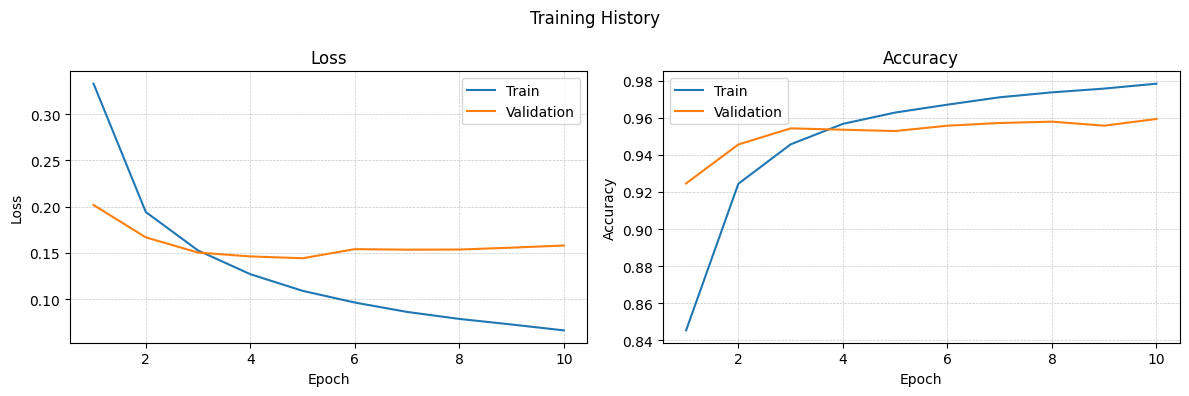

In [19]:
from building_tensorflow.utils import plot_training_history
plot_training_history(history)

353it [00:17, 19.65it/s]
2026-04-02 10:46:20.437804: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
43it [00:02, 20.62it/s]2026-04-02 10:46:22.905482: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
44it [00:02, 19.92it/s]


=== Binary classifier metrics : TEST SET===
Threshold: 0.3727  (best F2 threshold)
Accuracy : 0.9505
Precision: 0.8867
Recall   : 0.9738
F2 score : 0.9550
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9978


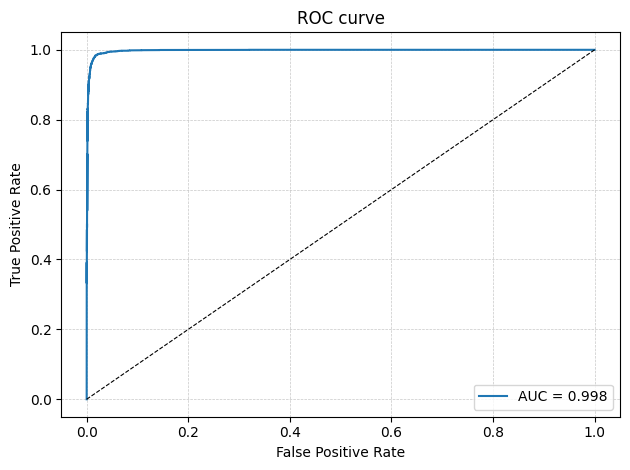

In [16]:
from building_tensorflow.utils import evaluate_binary_classifier
metrics = evaluate_binary_classifier(training_model,
 train_ds,
 test_ds,
  threshold=0.5,)

## Make frontend filters into a Conv1D inference model


In [17]:
# Extract the trained custom frontend and bake its filters
custom_layer = None
for layer in training_model.layers:
    if isinstance(layer, CustomFrontend):
        custom_layer = layer
        break

if custom_layer is None:
    raise RuntimeError("CustomFrontend layer not found in training_model")

baked_filters = custom_layer.get_filters().numpy()

# Build Conv1D-based inference model
infer_inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
x = keras.layers.Conv1D(
    filters=NUM_FILTERS,
    kernel_size=KERNEL_SIZE,
    strides=STRIDE,
    padding="valid",
    use_bias=False,
    name="baked_conv",
)(infer_inputs)
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(64, activation="relu", name="dense_hidden")(x)
infer_outputs = keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)

inference_model = keras.Model(infer_inputs, infer_outputs, name="sincnet_time_inference")

# Copy weights
inference_model.get_layer("baked_conv").set_weights([baked_filters])
inference_model.get_layer("dense_hidden").set_weights(
    training_model.layers[-2].get_weights()
)
inference_model.get_layer("dense_logits").set_weights(
    training_model.layers[-1].get_weights()
)

# Optional parity check on a small batch
for batch_audio, _ in test_ds.take(1):
    batch_audio_np = batch_audio.numpy()
    logits_train = training_model.predict(batch_audio_np, verbose=0)
    logits_infer = inference_model.predict(batch_audio_np, verbose=0)
    print("Max abs diff between training and inference logits:", np.max(np.abs(logits_train - logits_infer)))

Max abs diff between training and inference logits: 105.555214


2026-04-02 10:46:23.451794: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Export quantized TFLite model and Rust audio samples

We now export an int8-quantized TFLite model using the shared helpers from `building_tensorflow.utils`, and regenerate `audio_sample.rs` clips for the TinyChirp Rust runner.

In [18]:
# Build representative batches for post-training quantization
rep_batches = build_representative_batches(
    test_ds,
    target_len=TARGET_AUDIO_LEN_TIME,
    take=100,
)

# Export int8 TFLite model
try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

# Collect test clips and write Rust audio_sample.rs
clips = collect_test_clips_for_rs(
    DATASET_ROOT / "testing",
    sample_rate=SAMPLE_RATE,
    target_len=TARGET_AUDIO_LEN_TIME,
    num_per_label=2,
)

write_audio_sample_rs(
    OUT_AUDIO_RS,
    clips,
    SAMPLE_RATE,
    generator_name="building_tensorflow/sincnet_time.ipynb",
)

print(
    "Wrote",
    OUT_AUDIO_RS,
    "clips=",
    len(clips),
    "samples_per_clip=",
    len(clips[0][1]),
)

INFO:tensorflow:Assets written to: temp_saved_model/assets


2026-04-02 10:46:23.756743: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
INFO:tensorflow:Assets written to: temp_saved_model/assets


Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 47872, 1), dtype=tf.float32, name='keras_tensor_17')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  125547805640128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125547669575584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125547804945296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125547804944416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125547804943360: TensorSpec(shape=(), dtype=tf.resource, name=None)
Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_tf.tflite
Found 1393 files belonging to 2 classes.


W0000 00:00:1775119583.990964   16428 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1775119583.991187   16428 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-02 10:46:23.991690: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: temp_saved_model
2026-04-02 10:46:23.991976: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-02 10:46:23.991984: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: temp_saved_model
2026-04-02 10:46:23.995994: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-02 10:46:24.011038: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: temp_saved_model
2026-04-02 10:46:24.016331: I tensorflow/cc/saved_model/loader.cc:317] SavedModel load for tags { serve }; Status: success: OK. Took 24644 microseconds.
fully_quantize: 0, inference_type: 6, input_i

Wrote /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs clips= 4 samples_per_clip= 47872
